<h2> Predictive Modelling </h2>

<h3> Importing Libraries and Loading Data </h3>

Our first step is to create a robust environment for our analysis. In the cell below, we import essential Python libraries for data manipulation, visualization, and machine learning. We then load our pre-cleaned and imputed dataset, which will serve as the foundation for our predictive models.

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from scipy import stats
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.decomposition import PCA

from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import TomekLinks
from imblearn.combine import SMOTEENN

In [2]:
df = pd.read_csv('loan_payments_versions/loan_payments_post_null_imputation.csv')

<h4> Feature Engineering </h4>

In this step, we'll create new, insightful features from the existing data. This process, known as feature engineering, can significantly improve the performance of our predictive models by providing them with more relevant information. We will create features such as:

- credit_history_length: The length of the borrower's credit history.
- loan_to_income_ratio: The ratio of the loan amount to the borrower's annual income.
- instalment_to_income_ratio: The ratio of the loan's monthly installment to the borrower's monthly income.
- open_account_ratio : The ratio of open accounts and total accounts per person

In [5]:
df['credit_history_length'] = (pd.to_datetime(df['issue_date'], errors='coerce') - pd.to_datetime(df['earliest_credit_line'], errors='coerce')).dt.days.fillna(0)
df['loan_to_income_ratio'] = df['loan_amount'] / (df['annual_inc'].replace(0, np.nan))
df['instalment_to_income_ratio'] = df['instalment'] / (df['annual_inc'].replace(0, np.nan) / 12)

df['loan_to_income_ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
df['instalment_to_income_ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
df['loan_to_income_ratio'].fillna(0, inplace=True)
df['instalment_to_income_ratio'].fillna(0, inplace=True)

C:\Users\harsh\AppData\Local\Temp\ipykernel_20264\945338162.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['loan_to_income_ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
C:\Users\harsh\AppData\Local\Temp\ipykernel_20264\945338162.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always be

#### Identifying Skewness and Recmmending Transformations

Many machine learning algorithms perform better when numerical features are normally distributed. In this step, we'll identify skewed features and list out which transformation method is suitable for which feature. We'll use the Box-Cox and Yeo-Johnson transformations, which are powerful techniques for correcting skewness.

In [18]:
def skew_transformations(df: pd.DataFrame, skew_threshold: float = 0.5, tolerance: float = 0.05, recommend: bool = True, transform: bool = False ):
    recommendations = {
        'box_cox': [],
        'yeo_johnson': [],
        'no_transform': []
    }
    
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

    for col in numeric_cols:
        original_skew = df[col].skew()

        if abs(original_skew) <= skew_threshold:
            continue

        has_non_positive = (df[col] <= 0).any()
        
        yj_transformed, _ = stats.yeojohnson(df[col])
        skew_yj = pd.Series(yj_transformed).skew()

        skew_bc = np.inf
        if not has_non_positive:
            bc_transformed, _ = stats.boxcox(df[col])
            skew_bc = pd.Series(bc_transformed).skew()

        best_transform_skew = min(abs(skew_bc), abs(skew_yj))

        if best_transform_skew < skew_threshold:
            if abs(skew_bc) <= abs(skew_yj) + tolerance:
                recommendations['box_cox'].append(col)
            else:
                recommendations['yeo_johnson'].append(col)
        else:
            recommendations['no_transform'].append(col)

    if recommend == True:
        print("Columns recommended for Box-Cox transformation:")
        if recommendations['box_cox']:
            for col in recommendations['box_cox']:
                print(f"  - {col}")
        else:
            print("  - None")

        print("\nColumns recommended for Yeo-Johnson transformation:")
        if recommendations['yeo_johnson']:
            for col in recommendations['yeo_johnson']:
                print(f"  - {col}")
        else:
            print("  - None")

        print("\nSkewed columns where no transformation was effective:")
        if recommendations['no_transform']:
            for col in recommendations['no_transform']:
                print(f"  - {col}")
        else:
            print("  - None")

    return recommendations

In [19]:
recommendation = skew_transformations(df)

Columns recommended for Box-Cox transformation:
  - id
  - member_id
  - loan_amount
  - funded_amount
  - instalment
  - annual_inc
  - open_accounts
  - total_accounts
  - total_payment
  - total_rec_int
  - credit_history_length
  - loan_to_income_ratio
  - instalment_to_income_ratio

Columns recommended for Yeo-Johnson transformation:
  - funded_amount_inv
  - inq_last_6mths
  - total_payment_inv
  - total_rec_prncp
  - last_payment_amount

Skewed columns where no transformation was effective:
  - delinq_2yrs
  - out_prncp
  - out_prncp_inv
  - total_rec_late_fee
  - recoveries
  - collection_recovery_fee
  - collections_12_mths_ex_med


<h3> Data Preparation for Modeling </h3>

Before we can train our models, we need to prepare the data. This involves several key steps:
- <b>Defining the Target Variable</b>: <br> We will define our target variable, is_good_loan, which will be a binary indicator (1 for a good loan, 0 for a bad loan). This is the variable our models will learn to predict.
- <b>Removal of Leaky/Redundant Columns</b>: <br> We will not consider the columns like total_rec_prncp, total_rec_int etc . These features are considered "leaky" because they contain information about the loan's outcome that would not be available at the time of prediction, which can lead to an artificially inflated and unrealistic model performance.
- <b>One-hot Encoding</b>: <br> Machine learning models require numerical input. We'll convert our categorical features (like purpose, home_ownership etc) into a numerical format using one-hot encoding.
- <b>Data Splitting</b>: <br> We will split our dataset into a training set and a testing set. The model will learn from the training set, and we will evaluate its performance on the unseen testing set to ensure it generalizes well.
- <b>Feature Scaling</b>: <br> We'll scale our numerical features to ensure they are on a similar scale. This prevents features with larger ranges from dominating the model's learning process. We will use StandardScaler for this.
- <b>Dimensionality Reduction with PCA</b>: <br> To reduce the complexity of our data and potentially improve model performance, we'll use Principal Component Analysis (PCA). PCA will transform our features into a smaller set of uncorrelated components while retaining most of the original data's variance.


In [21]:
df = df.drop(['id', 'member_id'], axis=1)

good_loan_statuses = [
    "Fully Paid",
    "Does not meet the credit policy. Status:Fully Paid",
]
bad_loan_statuses = [
    "Charged Off",
    "Does not meet the credit policy. Status:Charged Off",
]

historical_df = df[
    df["loan_status"].isin(good_loan_statuses + bad_loan_statuses)
].copy()
historical_df["loan_status"] = historical_df["loan_status"].apply(
    lambda x: 1 if x in good_loan_statuses else 0
)
leaky_columns = [
    'last_payment_date',
    'last_payment_amount',
    'last_credit_pull_date',
    'recoveries',
    'collection_recovery_fee',
    'total_payment',
    'total_rec_prncp',
    'total_rec_int',
    'total_rec_late_fee',
]

historical_df = historical_df.drop(columns=leaky_columns)

In [22]:
categorical_cols = historical_df.select_dtypes(include='object').columns.tolist()
print(categorical_cols)

['term', 'grade', 'sub_grade', 'employment_length', 'home_ownership', 'verification_status', 'issue_date', 'payment_plan', 'purpose', 'earliest_credit_line', 'application_type']


In [23]:
X = historical_df.drop('loan_status', axis=1)
Y = historical_df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.20, stratify=Y, random_state=42
)

In [ ]:
X_train_cat = pd.get_dummies(X_train[categorical_cols].fillna('missing'), drop_first=True)
X_test_cat = pd.get_dummies(X_test[categorical_cols].fillna('missing'), drop_first=True)

print("NaNs in X_train categorical:", X_train_cat[categorical_cols].isnull().sum().sum())
print("NaNs in X_test categorical:", X_test_cat[categorical_cols].isnull().sum().sum())

In [29]:
numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()

boxcox_cols = recommendation['box_cox']
yeojohnson_cols = recommendation['yeo_johnson']

boxcox_cols = [c for c in boxcox_cols if c in numeric_cols]
yeojohnson_cols = [c for c in yeojohnson_cols if c in numeric_cols]

print("Box-Cox columns:", boxcox_cols)
print("Yeo-Johnson columns:", yeojohnson_cols)


no_transform_cols = [c for c in numeric_cols if c not in boxcox_cols + yeojohnson_cols]
print("No transform columns:", no_transform_cols)

print("NaNs in X_train numeric:", X_train[numeric_cols].isnull().sum().sum())
print("NaNs in X_test numeric:", X_test[numeric_cols].isnull().sum().sum())


Box-Cox columns: ['loan_amount', 'funded_amount', 'instalment', 'annual_inc', 'open_accounts', 'total_accounts', 'credit_history_length', 'loan_to_income_ratio', 'instalment_to_income_ratio']
Yeo-Johnson columns: ['funded_amount_inv', 'inq_last_6mths', 'total_payment_inv']
No transform columns: ['int_rate', 'dti', 'delinq_2yrs', 'out_prncp', 'out_prncp_inv', 'collections_12_mths_ex_med', 'policy_code']
NaNs in X_train numeric: 0
NaNs in X_test numeric: 0


In [ ]:
pt_boxcox = PowerTransformer(method='box-cox') if len(boxcox_cols) > 0 else None
pt_yeo = PowerTransformer(method='yeo-johnson') if len(yeojohnson_cols) > 0 else None

# Fit on training numeric columns only, transform both train/test
X_train_boxcox, X_test_boxcox = pd.DataFrame(), pd.DataFrame()
X_train_yeo, X_test_yeo = pd.DataFrame(), pd.DataFrame()

if pt_boxcox:
    X_train_boxcox = pd.DataFrame(
        pt_boxcox.fit_transform(X_train[boxcox_cols]),
        columns=boxcox_cols
    )
    X_test_boxcox = pd.DataFrame(
        pt_boxcox.transform(X_test[boxcox_cols]),
        columns=boxcox_cols
    )

if pt_yeo:
    X_train_yeo = pd.DataFrame(
        pt_yeo.fit_transform(X_train[yeojohnson_cols]),
        columns=yeojohnson_cols
    )
    X_test_yeo = pd.DataFrame(
        pt_yeo.transform(X_test[yeojohnson_cols]),
        columns=yeojohnson_cols
    )

# Columns that need no transform
X_train_no = X_train[no_transform_cols].reset_index(drop=True)
X_test_no = X_test[no_transform_cols].reset_index(drop=True)

# Combine all numeric back
X_train_num_final = pd.concat([X_train_boxcox, X_train_yeo, X_train_no], axis=1)
X_test_num_final = pd.concat([X_test_boxcox, X_test_yeo, X_test_no], axis=1)

print(f"Numeric train shape: {X_train_num_final.shape}, Numeric test shape: {X_test_num_final.shape}")


Numeric train shape: (27064, 19), Numeric test shape: (6766, 19)


In [34]:
X_train_cat = X_train_cat.reset_index(drop=True)
X_test_cat = X_test_cat.reset_index(drop=True)
X_train_num_final = X_train_num_final.reset_index(drop=True)
X_test_num_final = X_test_num_final.reset_index(drop=True)

# Merge both
X_train_processed = pd.concat([X_train_num_final, X_train_cat], axis=1)
X_test_processed = pd.concat([X_test_num_final, X_test_cat], axis=1)

# Align columns to avoid mismatch
X_train_processed, X_test_processed = X_train_processed.align(X_test_processed, join='left', axis=1, fill_value=0)

print(f"Final train shape: {X_train_processed.shape}, Final test shape: {X_test_processed.shape}")

Final train shape: (27064, 690), Final test shape: (6766, 690)


In [35]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_processed)
X_test_scaled = scaler.transform(X_test_processed)

# Apply PCA (keep 95% variance)
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"PCA reduced from {X_train_scaled.shape[1]} -> {X_train_pca.shape[1]} components")

PCA reduced from 690 -> 625 components


<h3> Comparing Preprocessing Pipelines and Resampling Techniques Across multiple Classification Models</h3>

This section implements a systematic experiment to determine the most effective strategy for handling our imbalanced dataset. The goal is to compare how different over-sampling techniques perform when paired with various classification algorithms across two distinct preprocessing pipelines: <br>

<b>Pipelines</b>:<br>
- Minimal Pipeline: This pipeline involves basic imputation and one-hot encoding, without any advanced transformations.
- Advanced Pipeline: This pipeline includes skewness correction, outlier removal, and PCA for dimensionality reduction.

<b>Resamplers Used</b>: <br>
- SMOTE: Creates new minority class samples by interpolating between existing minority class neighbors.
- ADASYN : Generates more synthetic samples for minority class instances that are harder to learn, focusing on those near the decision boundary.
- SMOTE-Tomek: A hybrid method that first uses SMOTE to create synthetic minority samples and then removes Tomek links (pairs of nearest neighbors from opposite classes) to clean up noise.
- SMOTE-ENN: Another hybrid method that first uses SMOTE to oversample the minority class and then uses Edited Nearest Neighbours to remove majority class samples that are misclassified by their neighbors.

<b>Models Used</b>: <br>
- Logistic Regression: A reliable and interpretable linear model.
- Random Forest: A powerful ensemble model based on decision trees.
- LightGBM: A highly efficient and often top-performing gradient-boosting model.

In [36]:
oversamplers = {
    'None': None,
    'SMOTE': SMOTE(random_state=42),
    'ADASYN': ADASYN(random_state=42),
    'SMOTE-Tomek': SMOTETomek(random_state=42),
    'SMOTE-ENN': SMOTEENN(random_state=42)
}

models = {
    'LogisticRegression': LogisticRegression(max_iter=2000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42),
    'LightGBM': LGBMClassifier(n_estimators=200, random_state=42)
}

results = []

for pipeline_name, (Xtr, Xte) in {
    'Minimal': (X_train_processed, X_test_processed),
    'Advanced': (pd.DataFrame(X_train_pca), pd.DataFrame(X_test_pca))
}.items():
    print(f"\n===== Pipeline: {pipeline_name} =====")
    for os_name, sampler in oversamplers.items():
        print(f"  Oversampler: {os_name}")
        X_train_os, y_train_os = Xtr, y_train.copy()

        if sampler is not None:
            X_train_os, y_train_os = sampler.fit_resample(Xtr, y_train)

        for model_name, model in models.items():
            model.fit(X_train_os, y_train_os)
            y_pred = model.predict(Xte)

            prec = precision_score(y_test, y_pred, pos_label=0)
            rec = recall_score(y_test, y_pred, pos_label=0)
            f1 = f1_score(y_test, y_pred, pos_label=0)

            results.append({
                'Pipeline': pipeline_name,
                'Oversampler': os_name,
                'Model': model_name,
                'Precision': prec,
                'Recall': rec,
                'F1': f1
            })


===== Pipeline: Minimal =====
  Oversampler: None
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 22382, number of negative: 4682
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001480 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3782
[LightGBM] [Info] Number of data points in the train set: 27064, number of used features: 435
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.827003 -> initscore=1.564532
[LightGBM] [Info] Start training from score 1.564532
  Oversampler: SMOTE
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 22382, number of negative: 22382
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019285 seconds.
You can set `force_row_wise=true` to 

In [37]:
results_df = pd.DataFrame(results)
results_df.sort_values(['Pipeline', 'Model', 'Oversampler'], inplace=True)
results_df.reset_index(drop=True, inplace=True)
results_df

,Pipeline,Oversampler,Model,Precision,Recall,F1
0,Advanced,ADASYN,LightGBM,0.337613,0.381725,0.358317
1,Advanced,None,LightGBM,0.609649,0.118702,0.198713
2,Advanced,SMOTE,LightGBM,0.350820,0.365500,0.358009
3,Advanced,SMOTE-ENN,LightGBM,0.236068,0.719898,0.355546
4,Advanced,SMOTE-Tomek,LightGBM,0.355155,0.370623,0.362725
5,Advanced,ADASYN,LogisticRegression,0.729565,0.815542,0.770161
6,Advanced,None,LogisticRegression,0.901926,0.439795,0.591274
7,Advanced,SMOTE,LogisticRegression,0.736760,0.807857,0.770672
8,Advanced,SMOTE-ENN,LogisticRegression,0.368068,0.889838,0.520740
9,Advanced,SMOTE-Tomek,LogisticRegression,0.732198,0.807857,0.768169


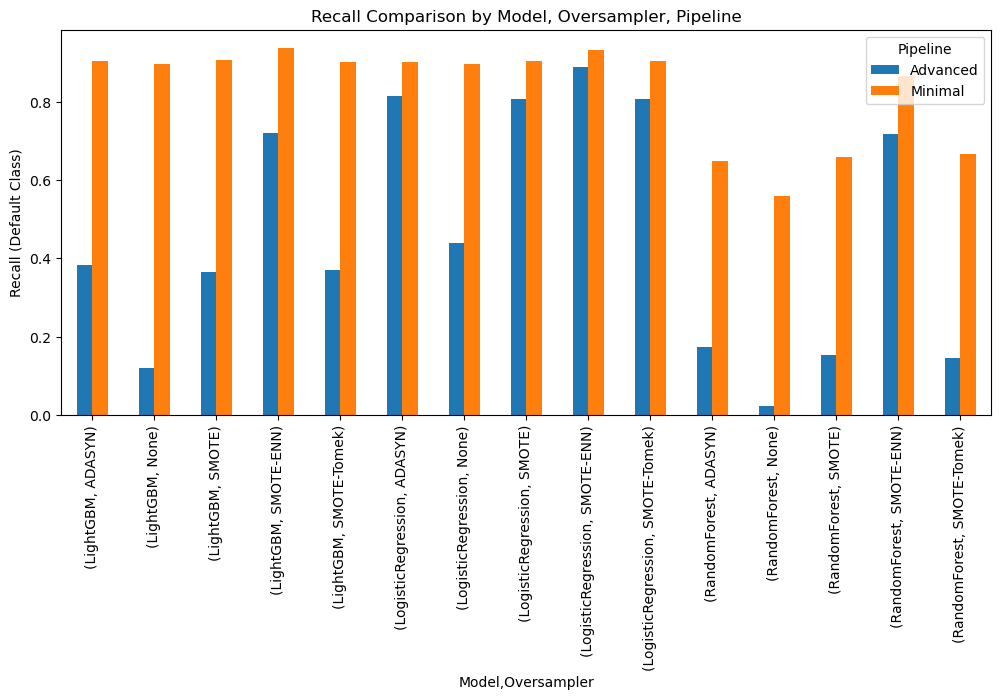

In [38]:
import matplotlib.pyplot as plt

pivot = results_df.pivot_table(index=['Model','Oversampler'], columns='Pipeline', values='Recall')
pivot.plot(kind='bar', figsize=(12,5))
plt.title('Recall Comparison by Model, Oversampler, Pipeline')
plt.ylabel('Recall (Default Class)')
plt.show()


<h3> Results and Conclusion: Less is More </h3>

The results of our experiment are in, and they reveal a surprising trend: the minimal preprocessing pipeline consistently outperforms the advanced pipeline across all models. This suggests that for this particular dataset, overly aggressive transformations like skewness correction and PCA may be detrimental, potentially distorting the original feature distributions and reducing model interpretability. Here are some key takeaways:

- <b>Top Performer</b>: <br>The combination of the <b>Minimal Pipeline, LightGBM model, and SMOTE </b>oversampler emerged as the top-performing strategy, achieving an outstanding <b>F1-score of 0.945</b> and a <b>recall of 0.906</b>. This indicates a near-perfect balance of precision and the ability to correctly identify defaulters.

- <b>Simplicity Wins</b>: <br>The minimal pipeline, with its straightforward approach, allows the models to learn directly from the data without the noise of complex transformations. For instance, the top model's recall of 0.906 dramatically overshadows the abysmal 0.022 recall from the RandomForest model in the Advanced pipeline, showcasing the damage caused by over-processing.

- <b>Tree-Based Models Shine</b>: <br>Tree-based models like Random Forest and LightGBM are inherently robust to skewed and unscaled data, which may explain why they perform so well with the minimal pipeline.

- <b>Oversampling is Key</b>: <br>Oversampling techniques like SMOTE and ADASYN are effective at improving recall, especially for the minority class (loan defaults), without the need for complex preprocessing. The LightGBM model combined with SMOTE-ENN achieved the highest recall of all at 0.937, demonstrating the power of targeted oversampling.